<a href="https://colab.research.google.com/github/demiana27/MobileNet-based-classifier-on-images-represented/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Multi-Domain Transfer Learning with MobileNetV2

This notebook trains and evaluates MobileNetV2 on CIFAR-10 using four different
image representations (domains):

| # | Domain | Representation |
|---|--------|----------------|
| 1 | **Spatial** | Raw RGB pixels (baseline) |
| 2 | **Fourier** | Log-magnitude of 2-D FFT |
| 3 | **Wavelet** | Haar DWT subbands (LL, LH, HL) |
| 4 | **Sobel** | Gradient magnitude (edge map) |

**Split**: 70% train / 15% val / 15% test (60k images, seed=42, same indices for all domains)

**Backbone**: MobileNetV2 (ImageNet pre-trained) — features frozen, classifier head fine-tuned

**Hyper-parameters**: identical for all four runs (Adam, lr=1e-3, wd=1e-4, 10 epochs, batch=64)

In [ ]:
import os
os.chdir('/content')
!ls

data	 domain.py  model.py	 runs	      train.py
data.py  drive	    __pycache__  sample_data  weights


## 0. Setup

In [ ]:
# Install dependencies (run once)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'torch', 'torchvision', 'PyWavelets',
                'scikit-learn', 'seaborn', 'matplotlib',
                'pandas', '--quiet'])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'torch', 'torchvision', 'PyWavelets', 'scikit-learn', 'seaborn', 'matplotlib', 'pandas', '--quiet'], returncode=0)

In [ ]:
import os
os.makedirs('runs/spatial', exist_ok=True)
os.makedirs('runs/fourier', exist_ok=True)
os.makedirs('runs/wavelet', exist_ok=True)
os.makedirs('runs/sobel', exist_ok=True)
os.makedirs('weights', exist_ok=True)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

from data    import get_loaders
from domain import DOMAIN_TRANSFORMS
from train import train_domain, CIFAR10_CLASSES

Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading & Split Verification

In [ ]:
# Build loaders for spatial domain (same split indices reused for all domains)
print('Loading CIFAR-10 (60k total = 42k train / 9k val / 9k test)...')
tf_train, tf_eval = DOMAIN_TRANSFORMS['spatial']()
train_loader, val_loader, test_loader = get_loaders(tf_train, tf_eval)

# Quick split size check
print(f'\nBatches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Loading CIFAR-10 (60k total = 42k train / 9k val / 9k test)...
  Train : 42,000  (70.0%)
  Val   :  9,000  (15.0%)
  Test  :  9,000  (15.0%)

Batches — train: 657 | val: 141 | test: 141


## 2. Visual Sample: One Batch per Domain

  Train : 42,000  (70.0%)
  Val   :  9,000  (15.0%)
  Test  :  9,000  (15.0%)


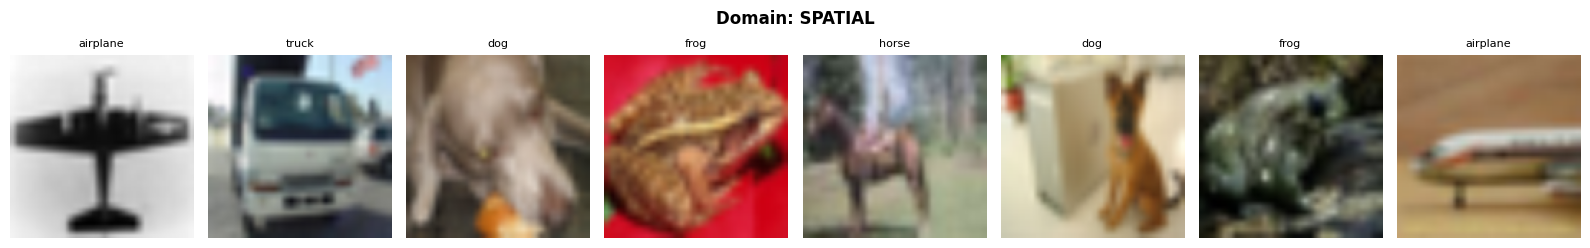

  Train : 42,000  (70.0%)
  Val   :  9,000  (15.0%)
  Test  :  9,000  (15.0%)


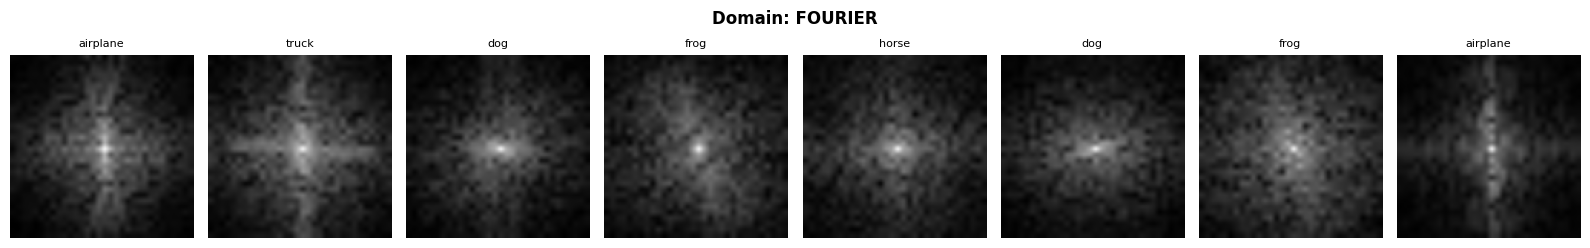

  Train : 42,000  (70.0%)
  Val   :  9,000  (15.0%)
  Test  :  9,000  (15.0%)


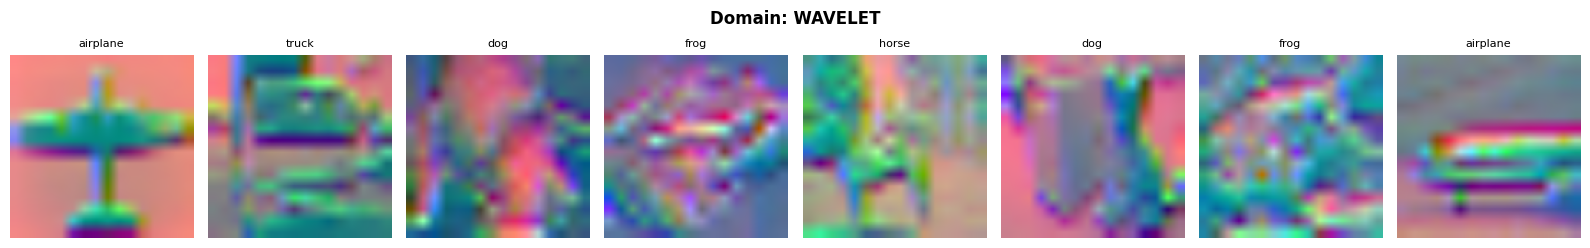

  Train : 42,000  (70.0%)
  Val   :  9,000  (15.0%)
  Test  :  9,000  (15.0%)


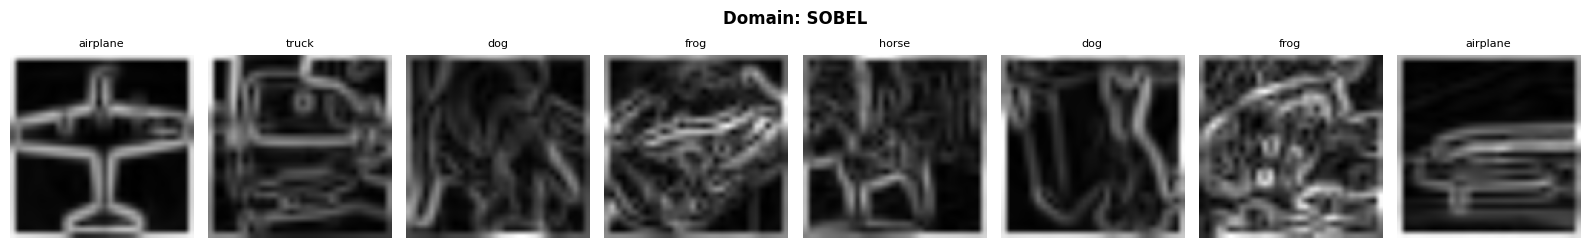

In [ ]:
def show_domain_batch(domain_name, n=8):
    """Display n sample images from a domain alongside their labels."""
    tf_tr, tf_ev = DOMAIN_TRANSFORMS[domain_name]()
    tl, _, _ = get_loaders(tf_tr, tf_ev)
    imgs, labels = next(iter(tl))

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    fig.suptitle(f'Domain: {domain_name.upper()}', fontsize=12, fontweight='bold')

    for i, ax in enumerate(axes):
        img = imgs[i].permute(1, 2, 0).numpy()
        # Undo NORM (mean=0.5, std=0.5) for display
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(CIFAR10_CLASSES[labels[i]], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'runs/{domain_name}/sample_images.png', dpi=100, bbox_inches='tight')
    plt.show()

import os
for d in DOMAIN_TRANSFORMS:
    os.makedirs(f'runs/{d}', exist_ok=True)
    show_domain_batch(d)

## 3. Training — All Four Domains

> Identical hyper-parameters for every run: **Adam · lr=1e-3 · wd=1e-4 · 10 epochs · batch=64**
>
> MobileNetV2 feature layers **frozen**; only the 1280→10 classifier head is trained.

In [ ]:
EPOCHS = 10
all_histories = {}

for domain in DOMAIN_TRANSFORMS:
    tf_tr, tf_ev = DOMAIN_TRANSFORMS[domain]()
    tl, vl, tsl  = get_loaders(tf_tr, tf_ev)
    history = train_domain(
        domain_name  = domain,
        train_loader = tl,
        val_loader   = vl,
        test_loader  = tsl,
        epochs       = EPOCHS,
        device       = DEVICE,
    )
    all_histories[domain] = history

  Train : 42,000  (70.0%)
  Val   :  9,000  (15.0%)
  Test  :  9,000  (15.0%)

  Domain : SPATIAL
  Device : cpu
  Epochs : 10  |  LR : 0.001  |  WD : 0.0001
  Total params    : 2,236,682
  Trainable params: 12,810
  Epoch  1/10  train_loss=0.7752  train_acc=0.7374  val_loss=0.6074  val_acc=0.7916  (798.7s)
  Epoch  2/10  train_loss=0.6595  train_acc=0.7726  val_loss=0.5873  val_acc=0.7991  (819.6s)
  Epoch  3/10  train_loss=0.6451  train_acc=0.7786  val_loss=0.6171  val_acc=0.7866  (820.6s)
  Epoch  4/10  train_loss=0.6416  train_acc=0.7780  val_loss=0.5868  val_acc=0.7971  (816.7s)
  Epoch  5/10  train_loss=0.6390  train_acc=0.7805  val_loss=0.5708  val_acc=0.8030  (828.7s)
  Epoch  6/10  train_loss=0.6323  train_acc=0.7821  val_loss=0.5670  val_acc=0.8053  (825.9s)
  Epoch  7/10  train_loss=0.6351  train_acc=0.7777  val_loss=0.5817  val_acc=0.7966  (831.4s)
  Epoch  8/10  train_loss=0.6430  train_acc=0.7780  val_loss=0.5655  val_acc=0.8052  (830.8s)
  Epoch  9/10  train_loss=0.6398 

## 4. Results Summary

In [ ]:
rows = []
for domain, h in all_histories.items():
    rows.append({
        'Domain'   : domain.capitalize(),
        'Train Acc': f"{max(h['train_acc']):.4f}",
        'Val Acc'  : f"{max(h['val_acc']):.4f}",
        'Test Acc' : f"{h['test_acc']:.4f}",
        'Test Loss': f"{h['test_loss']:.4f}",
    })

df = pd.DataFrame(rows)
print('\n=== Results Summary ===')
display(df)

## 5. Loss & Accuracy Curves (all domains overlay)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — All Domains', fontsize=14)

for domain, h in all_histories.items():
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['val_loss'], label=domain)
    axes[1].plot(ep, h['val_acc'],  label=domain)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('runs/all_domains_comparison.png', dpi=120)
plt.show()

## 6. Per-Domain Loss Curves (train vs val)

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Train vs Validation — Loss (top) & Accuracy (bottom)', fontsize=13)

for col, (domain, h) in enumerate(all_histories.items()):
    ep = range(1, len(h['train_loss']) + 1)

    axes[0, col].plot(ep, h['train_loss'], label='train')
    axes[0, col].plot(ep, h['val_loss'],   label='val')
    axes[0, col].set_title(f'{domain.capitalize()} — Loss')
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(ep, h['train_acc'], label='train')
    axes[1, col].plot(ep, h['val_acc'],   label='val')
    axes[1, col].set_title(f'{domain.capitalize()} — Acc')
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.savefig('runs/all_per_domain_curves.png', dpi=120)
plt.show()

## 7. Confusion Matrices (Test Set)

In [ ]:
import json, numpy as np

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14)

for ax, (domain, h) in zip(axes, all_histories.items()):
    cm = np.array(h['confusion_matrix'])
    sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c[:4] for c in CIFAR10_CLASSES],
                yticklabels=[c[:4] for c in CIFAR10_CLASSES],
                cbar=False)
    ax.set_title(domain.capitalize(), fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('runs/all_confusion_matrices.png', dpi=120)
plt.show()

## 8. Saved Weights

In [ ]:
import os
weight_files = [f for f in os.listdir('weights') if f.endswith('.pt')]
print('Saved weight files:')
for wf in sorted(weight_files):
    size_mb = os.path.getsize(f'weights/{wf}') / 1e6
    print(f'  weights/{wf}  ({size_mb:.1f} MB)')